<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB8(6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 6

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

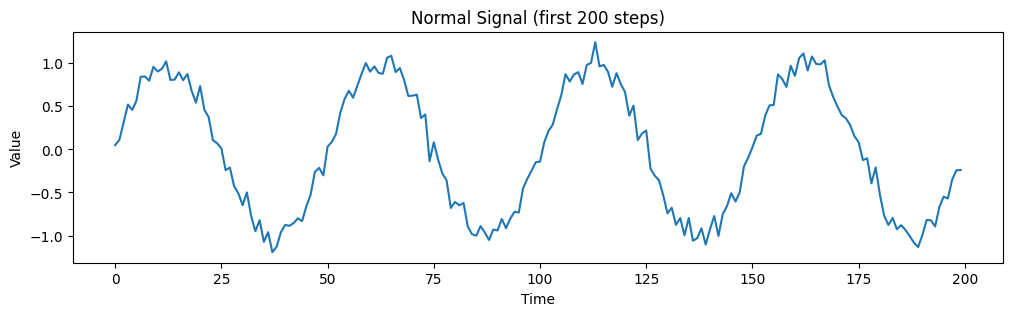

In [ ]:
np.random.seed(42)

# 1000 normal time steps (sine wave with small noise)
time = np.arange(1000)
normal_data = np.sin(2 * np.pi * time / 50) + np.random.normal(0, 0.1, 1000)

# Plot to see what normal looks like
plt.figure(figsize=(12, 3))
plt.plot(normal_data[:200])
plt.title("Normal Signal (first 200 steps)")
plt.xlabel("Time"); plt.ylabel("Value")
plt.show()

In [ ]:
SEQ_LEN = 30   # window size

def make_sequences(data, seq_len):
    X = []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
    return np.array(X).reshape(-1, seq_len, 1)

# Use ONLY normal data for training
X_train = make_sequences(normal_data, SEQ_LEN)
print("Training shape:", X_train.shape)   # (970, 30, 1)

Training shape: (970, 30, 1)


In [ ]:
model = models.Sequential([
    # --- Encoder ---
    layers.LSTM(32, activation='tanh', input_shape=(SEQ_LEN, 1),
                return_sequences=False),   # compress to a single vector

    # --- Bottleneck → repeat for decoder ---
    layers.RepeatVector(SEQ_LEN),          # repeat vector SEQ_LEN times

    # --- Decoder ---
    layers.LSTM(32, activation='tanh', return_sequences=True),
    layers.TimeDistributed(layers.Dense(1))  # one output per timestep
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, X_train,        # input = output (autoencoder)
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.3877 - val_loss: 0.2480
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.1394 - val_loss: 0.0419
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0362 - val_loss: 0.0274
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0247 - val_loss: 0.0215
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0212 - val_loss: 0.0192
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0200 - val_loss: 0.0200
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0198 - val_loss: 0.0191
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0180 - val_loss: 0.0165
Epoch 9/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0170 - val_loss: 0.0158
Epoch 10/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0163 - val_loss: 0.0153
Epoch 11/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0157 - val_loss: 0.0148
Epoch 12/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0

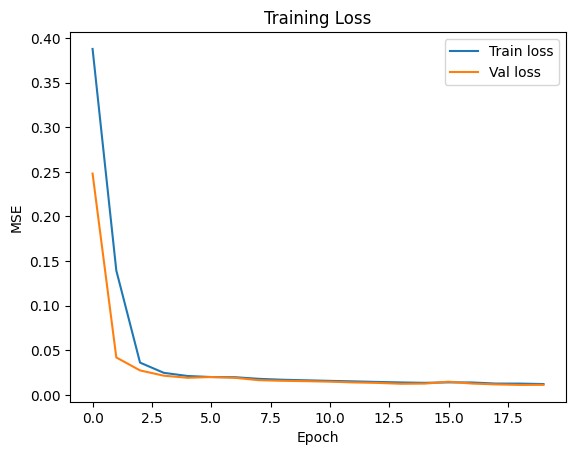

In [ ]:
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title("Training Loss"); plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.legend(); plt.show()

In [ ]:
# Start with a fresh normal test signal
test_data = np.sin(2 * np.pi * np.arange(500) / 50) + np.random.normal(0, 0.1, 500)

# Inject 3 anomaly spikes at specific positions
anomaly_positions = [100, 250, 400]
for pos in anomaly_positions:
    test_data[pos : pos + 5] += 5.0   # big spike

X_test = make_sequences(test_data, SEQ_LEN)
print("Test shape:", X_test.shape)

Test shape: (470, 30, 1)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


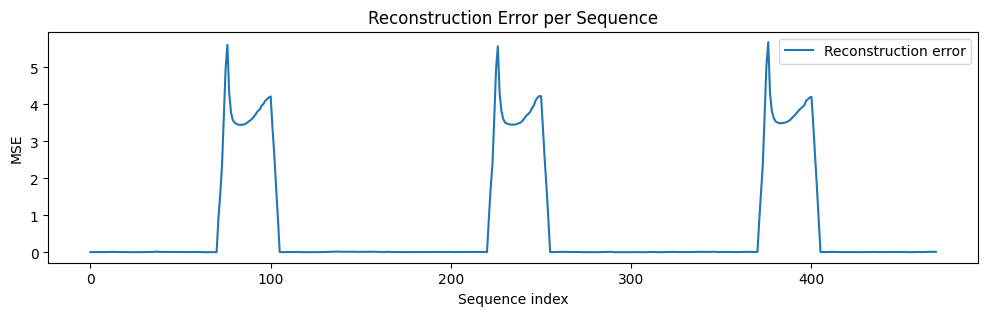

In [ ]:
X_pred = model.predict(X_test)

# Mean Squared Error per sequence
reconstruction_error = np.mean(np.power(X_test - X_pred, 2), axis=(1, 2))

plt.figure(figsize=(12, 3))
plt.plot(reconstruction_error, label='Reconstruction error')
plt.title("Reconstruction Error per Sequence")
plt.xlabel("Sequence index"); plt.ylabel("MSE")
plt.legend(); plt.show()

Anomaly threshold: 5.2465
Anomaly detected at sequence indices: [ 76 226 376]


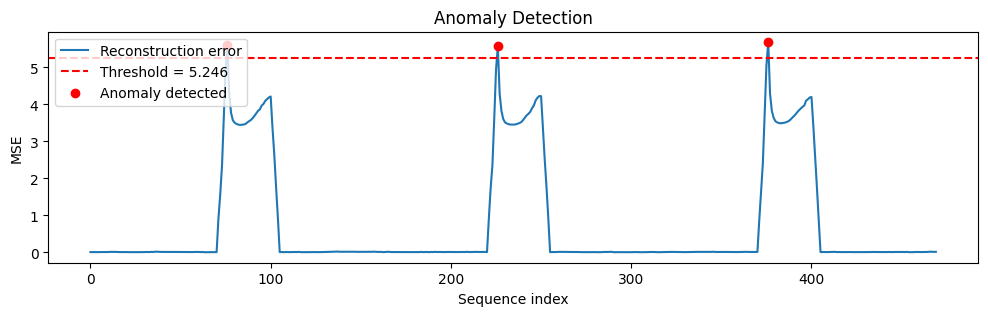

In [ ]:
# Threshold = mean + 3 standard deviations (common rule)
threshold = np.mean(reconstruction_error) + 3 * np.std(reconstruction_error)
print(f"Anomaly threshold: {threshold:.4f}")

anomalies = np.where(reconstruction_error > threshold)[0]
print(f"Anomaly detected at sequence indices: {anomalies}")

# Plot with threshold line
plt.figure(figsize=(12, 3))
plt.plot(reconstruction_error, label='Reconstruction error')
plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.3f}')
plt.scatter(anomalies, reconstruction_error[anomalies],
            color='red', zorder=5, label='Anomaly detected')
plt.title("Anomaly Detection")
plt.xlabel("Sequence index"); plt.ylabel("MSE")
plt.legend(); plt.show()